In [268]:
import sys
import uproot
import ROOT as r
import numpy as np
import array as arr
import awkward as ak
import os
import matplotlib.pyplot as plt
#from analysis import Analysis
import logging
import pickle
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
os.environ['MEDULLA_PLOT_DIR'] =  '/nashome/m/micarrig/icarus/nuESpine/medulla/spineplot/'
sys.path.append('/nashome/m/micarrig/icarus/nuESpine/medulla/spineplot/')
from efficiency import SpineEfficiency
from analysis import Analysis
#from efficiency import SpineEfficiency

%jsroot on 

r.gStyle.SetOptStat(0)

In [152]:
class selection():

    def __init__(self, name, label, operator='==', threshold=1, sel=None, nan_val=None):
        self.name = name
        self.label = label
        self.efficiency = -1.0
        self.purity = -1.0
        self.nu_efficiency = -1.0
        self.operator = operator  # '==', '!=', '<', '<=', '>', '>='
        self.threshold = threshold
        self.eff_den, self.eff_num = -1.0, -1.0
        self.pur_den, self.pur_num = -1.0, -1.0
        self.nu_eff_den, self.nu_eff_num = -1.0, -1.0
        self.sel = sel  # Optional custom selection function as a string
        self.nan_val = nan_val  # Value to replace NaNs with, if needed
    
    def apply_cut(self, branch_array):
        """Apply the cut based on operator and threshold"""
        if self.nan_val is not None:
            branch_array = np.where(np.isnan(branch_array), self.nan_val, branch_array)
        if self.sel is not None:
            print("Applying custom selection function:", self.sel, branch_array)
            branch_array = eval(self.sel)
            print("applied new branch", self.sel, branch_array)
            
        if self.operator == '==':
            return branch_array == self.threshold
        elif self.operator == '!=':
            return branch_array != self.threshold
        elif self.operator == '<':
            return branch_array < self.threshold
        elif self.operator == '<=':
            return branch_array <= self.threshold
        elif self.operator == '>':
            return branch_array > self.threshold
        elif self.operator == '>=':
            return branch_array >= self.threshold
        else:
            raise ValueError(f"Unknown operator: {self.operator}")

def print_selection_stats(selection_list):
    """Print name and efficiency/purity for each selection."""
    if not selection_list:
        print("No selections provided.")
        return

    headers = ("Selection", "Slice/Int Efficiency", "Neutrino Efficiency", "Purity")
    rows = []

    for sel in selection_list:
        eff_str = "N/A" if sel.efficiency == -1 else f"{sel.efficiency:.4f} ({sel.eff_num}/{sel.eff_den})"
        eff_nu_str = "N/A" if sel.nu_efficiency == -1 else f"{sel.nu_efficiency:.4f} ({sel.nu_eff_num}/{sel.nu_eff_den})"
        pur_str = "N/A" if sel.purity == -1 else f"{sel.purity:.4f} ({sel.pur_num}/{sel.pur_den})"
        rows.append((str(sel.label), eff_str, eff_nu_str, pur_str))

    sel_w = max([len(headers[0])] + [len(r[0]) for r in rows])
    w1 = max([len(headers[1])] + [len(r[1]) for r in rows])
    w2 = max([len(headers[2])] + [len(r[2]) for r in rows])
    w3 = max([len(headers[3])] + [len(r[3]) for r in rows])

    header_fmt = f"{{:<{sel_w}}}  {{:^{w1}}}  {{:^{w2}}}  {{:^{w3}}}"
    row_fmt = f"{{:<{sel_w}}}  {{:>{w1}}}  {{:>{w2}}}  {{:>{w3}}}"
    total_w = sel_w + w1 + w2 + w3 + 6

    print("\nSelection Summary")
    print(header_fmt.format(*headers))
    print("-" * total_w)
    for row in rows:
        print(row_fmt.format(*row))
    print("-" * total_w)

In [141]:
colors = [r.kBlack, r.kRed, r.kBlue, r.kGreen+2, r.kMagenta, r.kCyan+2, r.kOrange+7, r.kViolet+7, r.kAzure+7, r.kPink+7, r.kYellow+7]

def get_varHists(var, tree, bins=50, xmin=0, xmax=5):
    fullSel = ak.ones_like(tree[var].array(), dtype=bool)
    histograms = {}
    
    h = r.TH1F("h", "h", bins, xmin, xmax)

    data_array = tree[var].array()
    data_cleaned = ak.drop_none(ak.nan_to_none(ak.flatten(data_array, -1)), axis=None)

    eff_var = 'true_category'
    signal_index = 0  # Assuming category 0 is the signal
    true_nu = tree[eff_var].array()
    true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(tree[eff_var].array(), -1)), axis=None)

    total_entries = len(true_nu_flat[true_nu_flat == signal_index])
    for sel in selections:
        print(f"Applying selection: {sel.label}")
        # Use the apply_cut method instead of hardcoded == 1
        fullSel = fullSel & sel.apply_cut(tree[sel.name].array())
        h = r.TH1F("h", "h", bins, xmin, xmax)
        array_ = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[fullSel], -1)), axis=None)
        entries_ = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)), axis=None)
        entriesSel_ = len(entries_)
        entries_ = len(entries_[entries_ == signal_index])
        if sel.efficiency == -1: sel.efficiency = entries_/total_entries
        if sel.purity == -1: sel.purity = entries_/entriesSel_ if entriesSel_ > 0 else 0
        print(f"Efficiency after {sel.label}: {sel.efficiency:.4f} ({entries_}/{total_entries})")
        if len(array_) > 0:
            h.FillN(len(array_), arr.array('d', array_), np.ones(len(array_)))
        histograms[sel.label] = h
    
    return histograms

def plot_hists(histograms, selections, title, titleX, titleY, range=None):
    c1 = r.TCanvas("c1", "c1", 800, 600)

    l = r.TLegend(0.6,0.6,0.88,0.88) 

    maxY = max(hist.GetMaximum() for hist in histograms.values())               

    for ih, (key, hist) in enumerate(histograms.items()):
        hist.SetLineWidth(2)
        hist.SetLineColor(colors[ih % len(colors)])
        hist.SetTitle(f"{title}: {key}; {titleX}; {titleY}")

        if ih ==0 : 
            if range is not None:
                hist.GetYaxis().SetRangeUser(range[0], range[1])
            else:
                hist.GetYaxis().SetRangeUser(1, maxY*1.2)
            hist.Draw("")
        else: hist.Draw("SAME")

        l.AddEntry(hist, f'{key}, e={selections[ih].efficiency:.2f}, p={selections[ih].purity:.2f}', "l")

    l.Draw()
    c1.SetLogy()
    return c1, l

def get_effHists(var, tree, selections, total=None, bins=50, xmin=0, xmax=5, eff_var='true_category', nu_eff_var=None,signal_index=0, scale=1):
    fullSel = ak.ones_like(tree[var].array(), dtype=bool)
    histograms = {}

    data_array = tree[var].array() * scale
    data_cleaned = ak.drop_none(ak.nan_to_none(ak.flatten(data_array, -1)), axis=None)

    if isinstance(eff_var, np.ndarray):
        print("Using provided efficiency variable array")
        true_nu = eff_var
        true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu, -1)), axis=None)

    else:
        true_nu = tree[eff_var].array()
        true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(tree[eff_var].array(), -1)), axis=None)

    total_entries = len(true_nu_flat[true_nu_flat == signal_index])
    
    # Create denominator histogram once with only signal events
    signal_mask = true_nu == signal_index
    total_signal_array = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[signal_mask], -1)), axis=None)
    
    for sel in selections:
        print(f"Applying selection: {sel.label}")
        # Use the apply_cut method instead of hardcoded == 1
        fullSel = fullSel & sel.apply_cut(tree[sel.name].array())

        if isinstance(bins, arr.array):
            h_num = r.TH1F("h_num", "h_num", len(bins)-1, bins)
            h_den = r.TH1F("h_den", "h_den", len(bins)-1, bins)
        else:
            h_num = r.TH1F("h_num", "h_num", bins, xmin, xmax)
            h_den = r.TH1F("h_den", "h_den", bins, xmin, xmax)
        g_ratio = r.TGraphAsymmErrors()
        
        # Numerator: selected events that are signal
        combined_mask = fullSel & signal_mask
        array_ = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[combined_mask], -1)), axis=None)
        
        print(f"total entries in selection: {len(ak.flatten(true_nu[fullSel], -1))}")
        entries_ = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)), axis=None)
        entriesSel_ = len(entries_)
        print(f"Selected entries: {entriesSel_}")
        entries_ = len(entries_[entries_ == signal_index])
        print(f"Purity: {entries_}/{entriesSel_} = {entries_/entriesSel_ if entriesSel_ > 0 else 0:.4f}")
        if sel.efficiency == -1: 
            sel.efficiency = entries_/total_entries if total_entries > 0 else 0
            sel.eff_den = total_entries
            sel.eff_num = entries_
        if sel.purity == -1: 
            sel.purity = entries_/entriesSel_ if entriesSel_ > 0 else 0
            sel.pur_den = entriesSel_
            sel.pur_num = entries_
        if total is not None and sel.nu_efficiency == -1: 
            if nu_eff_var is not None:
                nu_eff_num = ak.nan_to_none(ak.flatten(tree[nu_eff_var].array()[fullSel], -1))
                none_mask = ~ak.is_none(nu_eff_num)
                true_nu_sel = ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)[none_mask] == signal_index)
                nu_eff_num = nu_eff_num[none_mask]
                print(len(nu_eff_num), len(true_nu_sel))
                nu_eff_num = len(np.unique(ak.to_numpy(nu_eff_num[true_nu_sel])))
            else:
                nu_eff_num = entries_
            sel.nu_efficiency = nu_eff_num/total if total > 0 else 0
            sel.nu_eff_den = total
            sel.nu_eff_num = nu_eff_num
        print(f"Efficiency after {sel.label}: {sel.efficiency:.4f} ({entries_}/{total_entries})")
        
        # Fill numerator with selected signal events
        if len(array_) > 0:
            h_num.FillN(len(array_), arr.array('d', array_), np.ones(len(array_)))
        
        # Fill denominator with all signal events (denominator is constant)
        if len(total_signal_array) > 0:
            h_den.FillN(len(total_signal_array), arr.array('d', total_signal_array), np.ones(len(total_signal_array)))

        g_ratio = r.TGraphAsymmErrors(h_num, h_den)
        
        histograms[sel.label] = g_ratio
    
    return histograms

In [66]:
fall = uproot.open("/nashome/m/micarrig/sbnd/nueCCNp/output_nueCCNp.root:events/signal/all")
fsel = uproot.open("/nashome/m/micarrig/sbnd/nueCCNp/output_nueCCNp.root:events/signal/true_signal")

### Breakdown of signal vs backgrounds

In [168]:
selections = []
selections.append(selection("reco_no_cut", "No Cut"))
selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
selections.append(selection("reco_flash_cut", "Flash Cut"))
#selections.append(selection("reco_valid_flashmatch", "Valid Flash Match"))
selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
selections.append(selection("reco_vertex_distance_cut", "Vertex Distance < 3.25 cm"))
#selections.append(selection("reco_track_length", "Longest Track Length < 190 cm"))
selections.append(selection("reco_has_electron", ">=1 Electron-like Particle"))
selections.append(selection("reco_no_muons", "0 Muon-like Particles", operator='==', threshold=1))
#selections.append(selection("reco_leading_electron_containment_cut", "Leading Electron Containment Cut"))
selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.72", operator='>', threshold=0.72))
selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.97", operator='>', threshold=0.97))
selections.append(selection("reco_leading_electron_energy", "Leading Electron Energy > 225 MeV", operator='>', threshold=225))
# selections.append(selection("reco_leading_pion_pion_softmax", "Leading Pion Softmax > 0.6", operator='==', threshold=1, sel="np.where((branch_array >= 0.6) | (branch_array <= 0), 1, 0)", nan_val=-999))
# selections.append(selection("reco_leading_pion_primary_softmax", "Leading Pion Primary Softmax > 0.6", operator='==', threshold=1, sel="np.where((branch_array >= 0.6) | (branch_array <= 0), 1, 0)", nan_val=-999))
# selections.append(selection("reco_leading_pion_energy", "Leading Pion Energy > 160 MeV", operator='==', threshold=1, sel="np.where((branch_array >= 160) | (branch_array <= 0), 1, 0)", nan_val=-999))
# selections.append(selection("reco_leading_electron_electron_softmax_cut", "Leading Electron Softmax > 0.72", operator='==', threshold=1))
# selections.append(selection("reco_leading_electron_primary_softmax_cut", "Leading Electron Primary Softmax > 0.97", operator='==', threshold=1))
#selections.append(selection("reco_leading_electron_muon_softmax", "Leading Electron Muon Softmax < 0.01", operator='<', threshold=0.01))
#selections.append(selection("reco_leading_electron_photon_softmax", "Leading Electron Photon Softmax < 0.2", operator='<', threshold=0.1))
#selections.append(selection("reco_particle_dedx", "Electron dE/dx < 3.625 MeV/cm"))

true_selections = []
true_selections.append(selection("true_fiducial_cut", "True Fiducial Cut"))
true_selections.append(selection("true_has_electron", "True Has Electron"))
true_selections.append(selection("true_has_proton", "True Has Proton"))
true_selections.append(selection("true_no_muons", "True No Muons"))
true_selections.append(selection("true_no_charged_pions", "True No Charged Pions"))
true_selections.append(selection("true_containment_cut", "True Containment Cut"))

In [169]:
true_category = fall['true_category'].array(library="np")
true_category_truth = fsel['true_category'].array(library="np")

sel_mask = np.ones_like(true_category, dtype=bool)
for sel in selections:
    this_mask = sel.apply_cut(fall[sel.name].array(library="np"))
    sel_mask &= this_mask

sel_mask_truth = np.ones_like(true_category_truth, dtype=bool)
for sel in selections:
    this_mask = sel.apply_cut(fsel[sel.name].array(library="np"))
    sel_mask_truth &= this_mask

# true_mask = np.ones_like(true_category, dtype=bool)
# for sel in true_selections:
#     this_mask = sel.apply_cut(fall[sel.name].array(library="np"))
#     true_mask &= this_mask

true_category_sel = true_category[sel_mask]
true_category_sel_truth = true_category_truth[sel_mask_truth]

In [170]:
labels = {0: 'Signal', 1: r'$\nu_{e}$ CC OOFV', 2: r'$\nu_{\mu}$', 3: 'OOFV', 4: 'NC', 5: 'Cosmic'}
category_colors = ['#001261', '#1E6F9D', '#EACEBD', '#BE6533','#8B2706', '#590008']


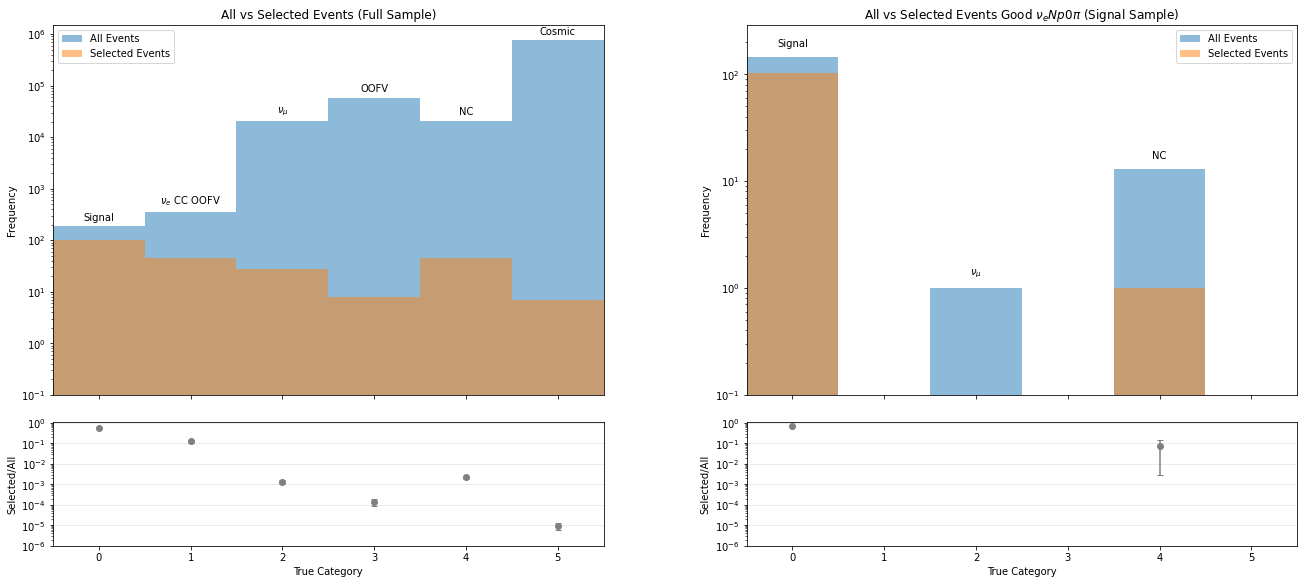

In [171]:
# Two side-by-side panels; each panel has (hist, ratio) stacked.
# For now both panels intentionally show the same content.

cat_bins = np.arange(-0.5, 6.5, 1)
centers = (cat_bins[:-1] + cat_bins[1:]) / 2

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 8),
    sharex='col',
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05, "wspace": 0.15},
    constrained_layout=True,
)

categories = [true_category, true_category_truth]
categories_sel = [true_category_sel, true_category_sel_truth]
titles = ["All vs Selected Events (Full Sample)", r"All vs Selected Events Good $\nu_{e}Np0\pi$ (Signal Sample)"]

for col in range(2):
    ax_hist = axes[0, col]
    ax_ratio = axes[1, col]

    ax_hist.hist(categories[col], bins=cat_bins, label="All Events", alpha=0.5)
    ax_hist.hist(categories_sel[col], bins=cat_bins, label="Selected Events", alpha=0.5)
    ax_hist.set_ylabel("Frequency")
    ax_hist.set_title(titles[col])
    ax_hist.legend()
    ax_hist.set_yscale("log")

    all_hist, _ = np.histogram(categories[col], bins=cat_bins)
    sel_hist, _ = np.histogram(categories_sel[col], bins=cat_bins)

    ax_hist.set_ylim(0.1, max(all_hist.max(), sel_hist.max()) * 2.0)

    ratio = np.divide(
        sel_hist,
        all_hist,
        out=np.zeros_like(sel_hist, dtype=float),
        where=all_hist > 0,
    )
    ratio_err = np.sqrt(
        np.divide(
            ratio * (1 - ratio),
            all_hist,
            out=np.zeros_like(ratio, dtype=float),
            where=all_hist > 0,
        )
    )

    # Annotate bin labels above bars
    for i, c in enumerate(all_hist):
        if c <= 0:
            continue
        label = labels.get(i, str(i))
        ax_hist.text(i, c * 1.2, label, ha="center", va="bottom", fontsize=10)

    ax_ratio.errorbar(centers, ratio, yerr=ratio_err, fmt="o", color="gray", capsize=3)
    ax_ratio.set_xlabel("True Category")
    ax_ratio.set_ylabel("Selected/All")
    ax_ratio.set_xticks(centers)
    ax_ratio.set_xlim(cat_bins[0], cat_bins[-1])
    ax_ratio.set_ylim(1e-6, 1.05)
    ax_ratio.grid(axis="y", alpha=0.3)
    ax_ratio.set_yscale("log")

plt.show()


/tmp/ipykernel_1893/2156266731.py:39: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(
/tmp/ipykernel_1893/2156266731.py:70: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


Text(0, 0.5, 'S/B')

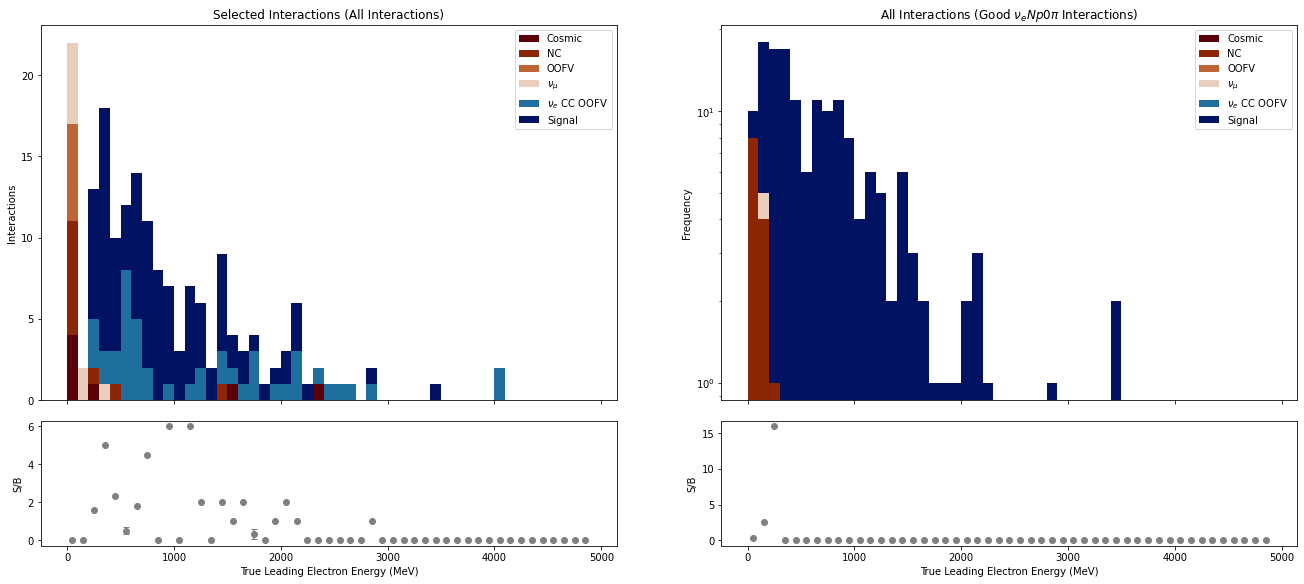

In [172]:
true_leading_electron_energy = fall['true_leading_electron_energy'].array(library="np")
true_leading_electron_energy_truth = fsel['true_leading_electron_energy'].array(library="np")

bins = np.arange(0, 5000, 100)
centers = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots(
    2, 2,
    figsize=(18, 8),
    sharex='col',
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05, "wspace": 0.1},
    constrained_layout=True)

vals = []
vals_sel = []
for cat in labels.keys():
    cat_mask = true_category == cat
    cat_mask_truth = true_category_truth == cat
    vals.append(true_leading_electron_energy_truth[cat_mask_truth])
    vals_sel.append(true_leading_electron_energy[cat_mask & sel_mask])

ax[0, 0].hist(vals_sel[::-1], bins=bins, label=list(labels.values())[::-1], stacked=True, color=category_colors[::-1])
ax[0, 0].set_ylabel('Interactions')
ax[0, 0].set_title('Selected Interactions (All Interactions)')
ax[0, 0].legend()

signal_hist, _ = np.histogram(vals_sel[0], bins=bins)
background_vals = [v[np.isfinite(v)] for v in vals_sel[1:] if len(v) > 0]
background_vals = np.concatenate(background_vals) if background_vals else np.array([])

sel_hist, _ = np.histogram(background_vals, bins=bins)

ratio = np.divide(
    signal_hist,
    sel_hist,
    out=np.zeros_like(sel_hist, dtype=float),
    where=sel_hist > 0,
)
ratio_err = np.sqrt(
    np.divide(
        ratio * (1 - ratio),
        sel_hist,
        out=np.zeros_like(ratio, dtype=float),
        where=sel_hist > 0,
    )
)

ax[1, 0].errorbar(centers, ratio, yerr=ratio_err, fmt="o", color="gray", capsize=3)
ax[1, 0].set_xlabel("True Leading Electron Energy (MeV)")
ax[1, 0].set_ylabel("S/B")

ax[0, 1].hist(vals[::-1], bins=bins, label=list(labels.values())[::-1], stacked=True, color=category_colors[::-1])
ax[0, 1].set_ylabel('Frequency')
ax[0, 1].set_title(r'All Interactions (Good $\nu_{e}Np0\pi$ Interactions)')
ax[0, 1].legend()
ax[0, 1].set_yscale('log')

signal_hist, _ = np.histogram(vals[0], bins=bins)
background_vals = [v[np.isfinite(v)] for v in vals[1:] if len(v) > 0]
background_vals = np.concatenate(background_vals) if background_vals else np.array([])

sel_hist, _ = np.histogram(background_vals, bins=bins)

ratio = np.divide(
    signal_hist,
    sel_hist,
    out=np.zeros_like(sel_hist, dtype=float),
    where=sel_hist > 0,
)
ratio_err = np.sqrt(
    np.divide(
        ratio * (1 - ratio),
        sel_hist,
        out=np.zeros_like(ratio, dtype=float),
        where=sel_hist > 0,
    )
)

ax[1, 1].errorbar(centers, ratio, yerr=ratio_err, fmt="o", color="gray", capsize=3)
ax[1, 1].set_xlabel("True Leading Electron Energy (MeV)")
ax[1, 1].set_ylabel("S/B")

In [173]:
def plot_hist(vals, bins, labels, colors, truth_category, title):

    centers = (bins[:-1] + bins[1:]) / 2

    fig, ax = plt.subplots(
        2, 1,
        figsize=(10, 8),
        gridspec_kw={"height_ratios": [3, 1]})

    l_vals = []
    for cat in labels.keys():
        cat_mask = truth_category == cat
        l_vals.append(vals[cat_mask])

    ax[0].hist(l_vals[::-1], bins=bins, label=list(labels.values())[::-1], stacked=True, color=colors[::-1])
    ax[0].set_ylabel('Interactions')
    ax[0].legend()

    signal_hist, _ = np.histogram(l_vals[0], bins=bins)
    background_vals = [v[np.isfinite(v)] for v in l_vals[1:] if len(v) > 0]
    background_vals = np.concatenate(background_vals) if background_vals else np.array([])

    sel_hist, _ = np.histogram(background_vals, bins=bins)

    ratio = np.divide(
        signal_hist,
        sel_hist,
        out=np.zeros_like(sel_hist, dtype=float),
        where=sel_hist > 0,
    )
    ratio_err = np.sqrt(
        np.divide(
            ratio * (1 - ratio),
            sel_hist,
            out=np.zeros_like(ratio, dtype=float),
            where=sel_hist > 0,
        )
    )

    ax[1].errorbar(centers, ratio, yerr=ratio_err, fmt="o", color="gray", capsize=3)
    ax[1].set_xlabel(title)
    ax[1].set_ylabel("S/B")

    return fig, ax

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


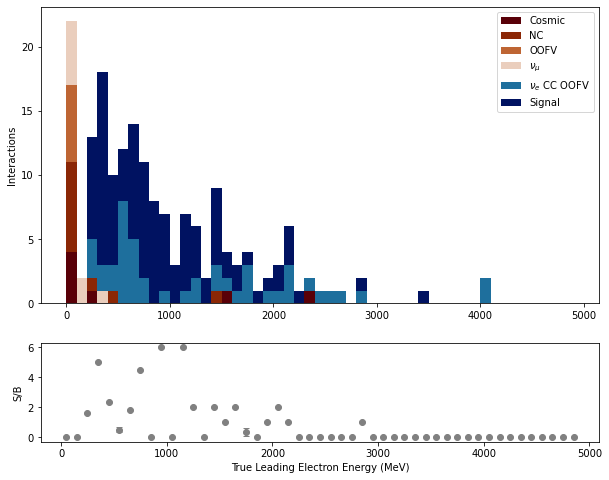

In [174]:
true_leading_electron_energy = fall['true_leading_electron_energy'].array(library="np")
true_leading_electron_energy_sel = true_leading_electron_energy[sel_mask]

ax, fig = plot_hist(
    vals=true_leading_electron_energy_sel,
    bins=np.arange(0, 5000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="True Leading Electron Energy (MeV)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


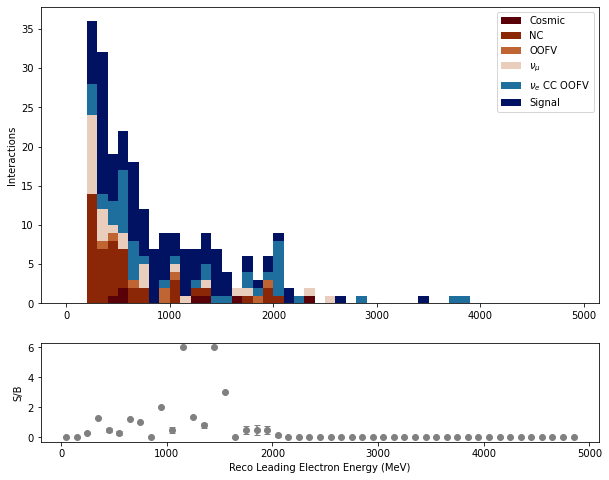

In [175]:
vals = fall['reco_leading_electron_energy'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 5000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Leading Electron Energy (MeV)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


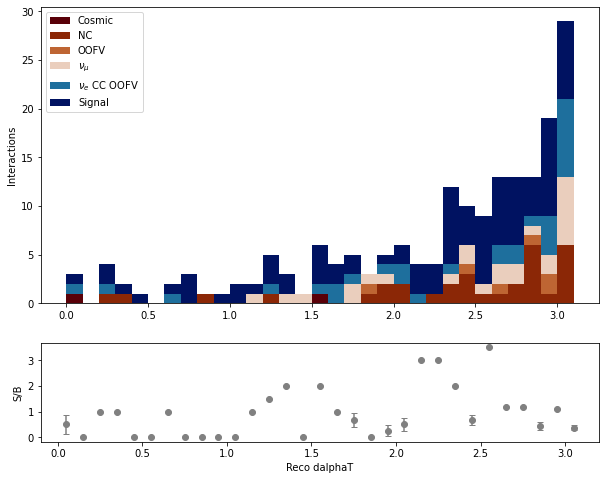

In [198]:
vals = fall['reco_dalphaT'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 3.2, 0.1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco dalphaT"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


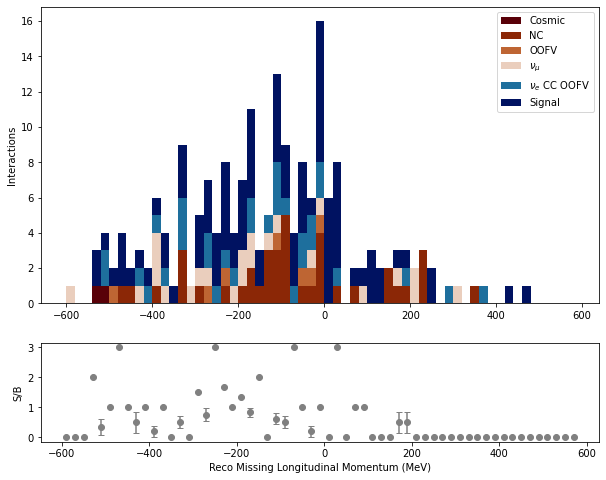

In [197]:
vals = fall['reco_dpL'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-600, 600, 20),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Missing Longitudinal Momentum (MeV)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


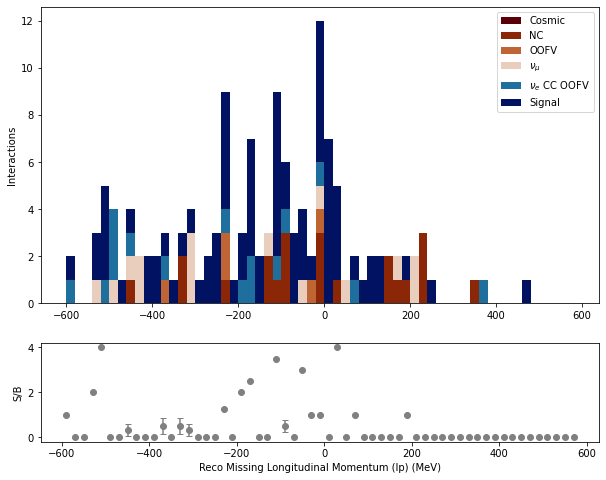

In [196]:
vals = fall['reco_dpL_lp'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-600, 600, 20),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Missing Longitudinal Momentum (lp) (MeV)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


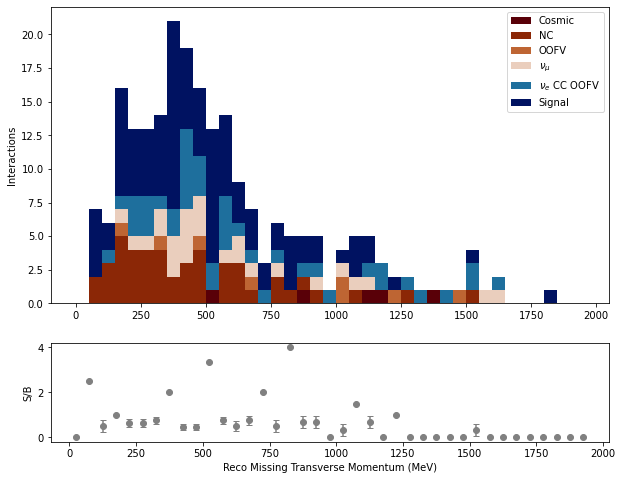

In [200]:
vals = fall['reco_dpT'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 2000, 50),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Missing Transverse Momentum (MeV)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


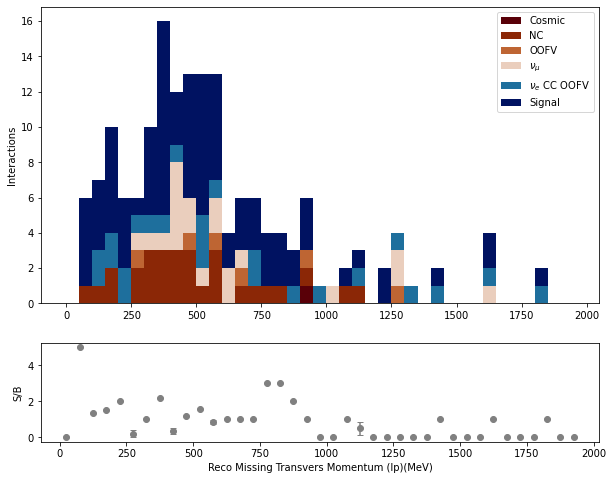

In [202]:
vals = fall['reco_dpT_lp'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 2000, 50),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Missing Transvers Momentum (lp)(MeV)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


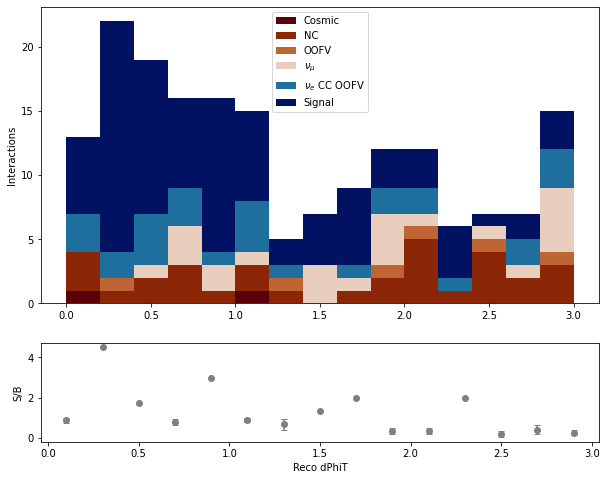

In [205]:
vals = fall['reco_dphiT'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 3.2, 0.2),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco dPhiT"
)

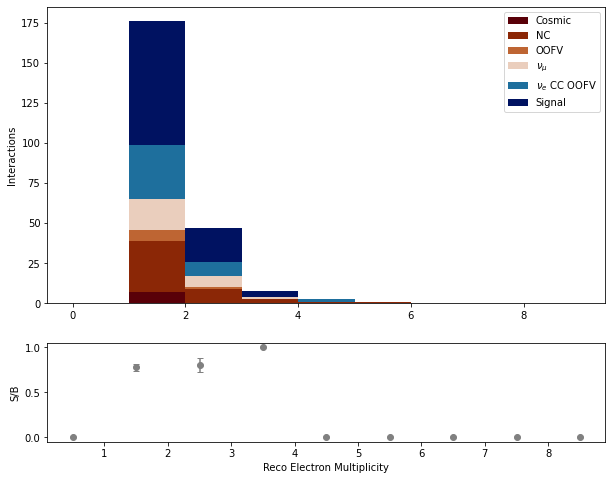

In [206]:
vals = fall['reco_electron_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 10, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Multiplicity"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


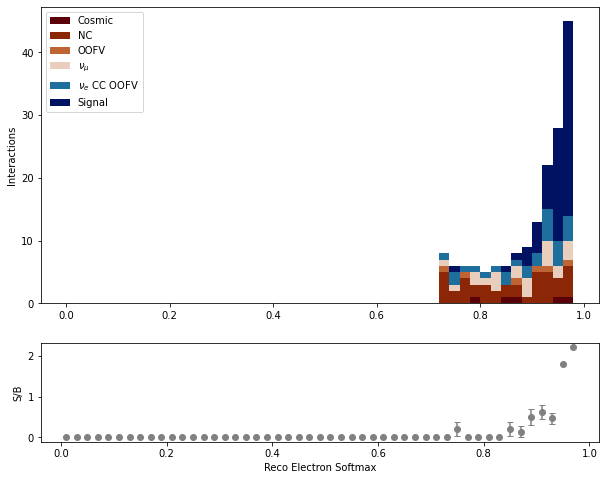

In [220]:
vals = fall['reco_leading_electron_electron_softmax'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 1, 0.02),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Softmax"
)

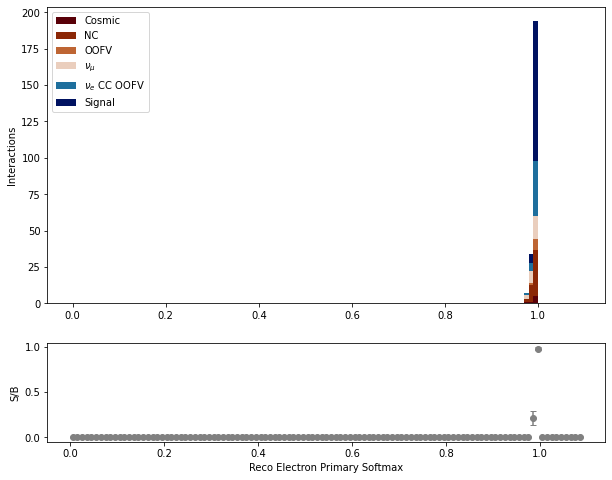

In [221]:
vals = fall['reco_leading_electron_primary_softmax'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 1.1, 0.01),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Primary Softmax"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


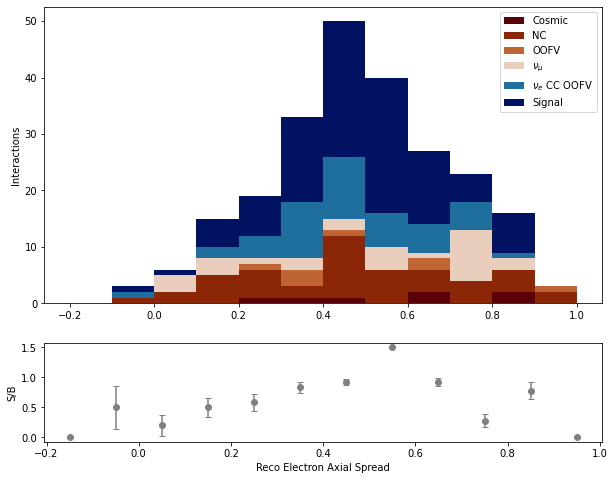

In [225]:
vals = fall['reco_leading_electron_axial_spread'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-0.2, 1.1, 0.1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Axial Spread"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


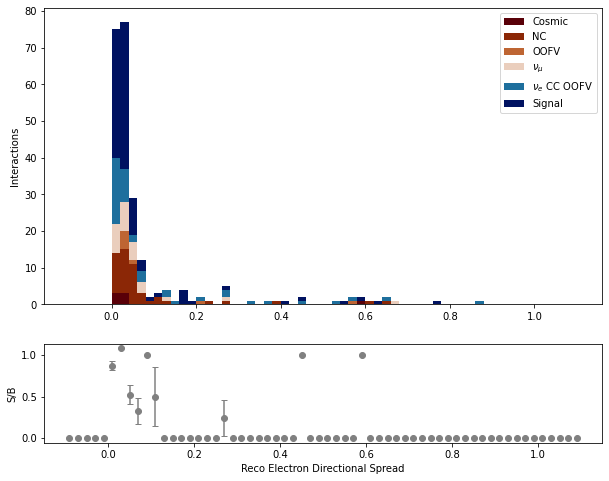

In [229]:
vals = fall['reco_leading_electron_directional_spread'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-0.1, 1.1, 0.02),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Directional Spread"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


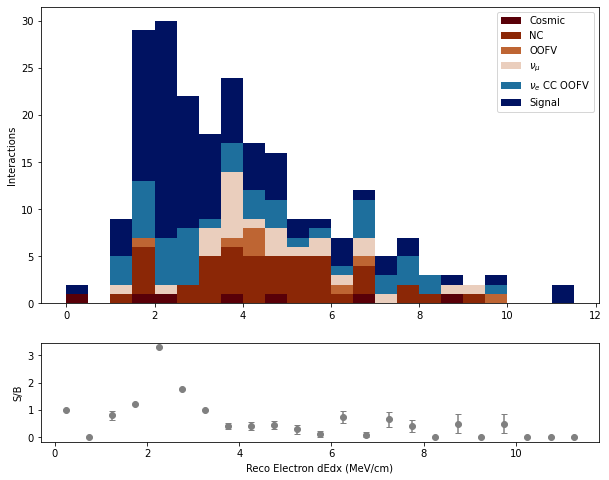

In [231]:
vals = fall['reco_leading_electron_start_dedx'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 12, 0.5),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron dEdx (MeV/cm)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


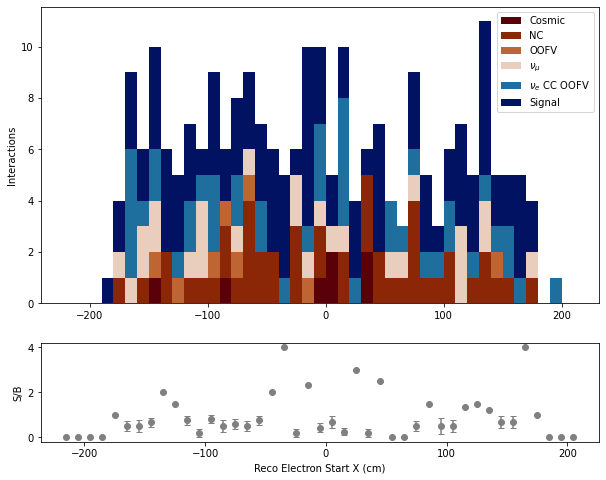

In [235]:
vals = fall['reco_leading_electron_start_x'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-220, 220, 10),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Start X (cm)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


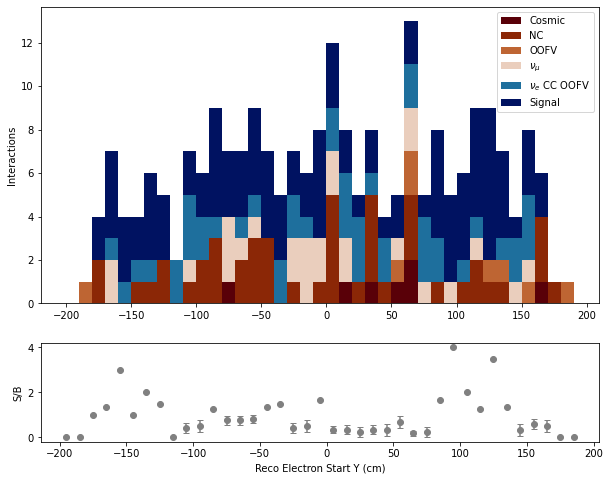

In [237]:
vals = fall['reco_leading_electron_start_y'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-200, 200, 10),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Start Y (cm)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


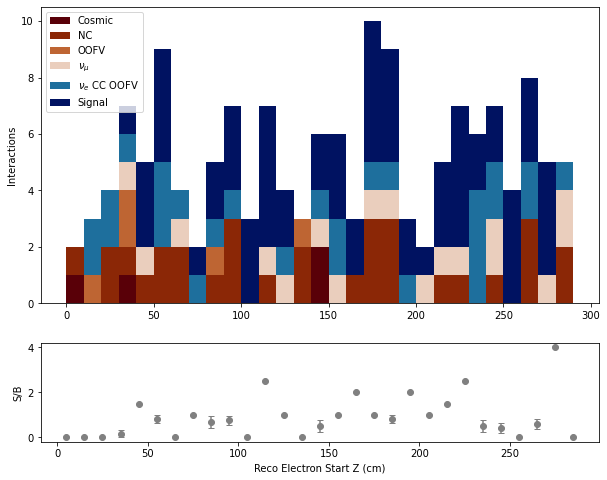

In [239]:
vals = fall['reco_leading_electron_start_z'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 300, 10),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Start Z (cm)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


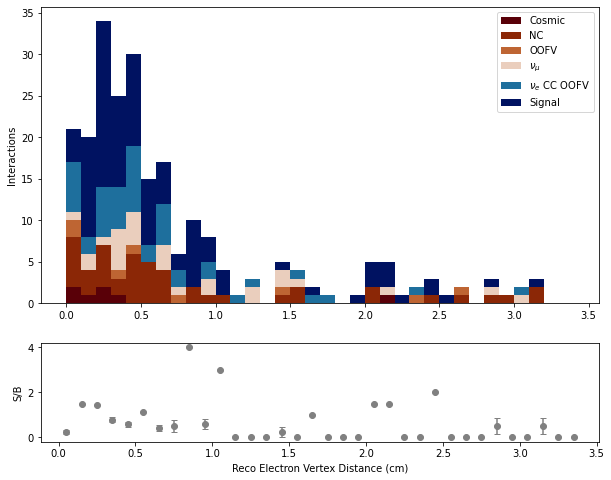

In [244]:
vals = fall['reco_leading_electron_vertex_distance'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 3.5, 0.1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Vertex Distance (cm)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


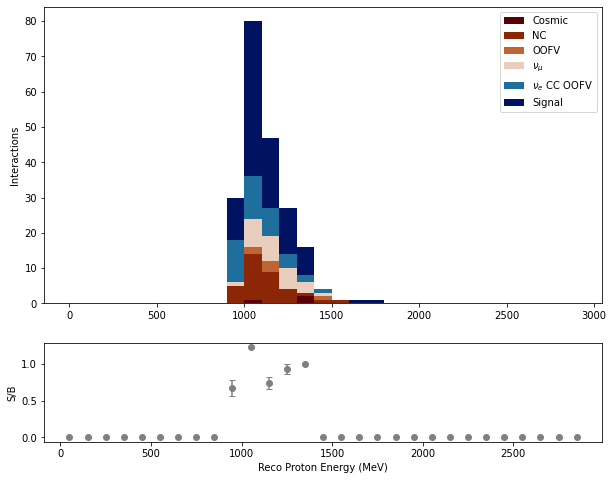

In [247]:
vals = fall['reco_leading_proton_energy'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 3000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Energy (MeV)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


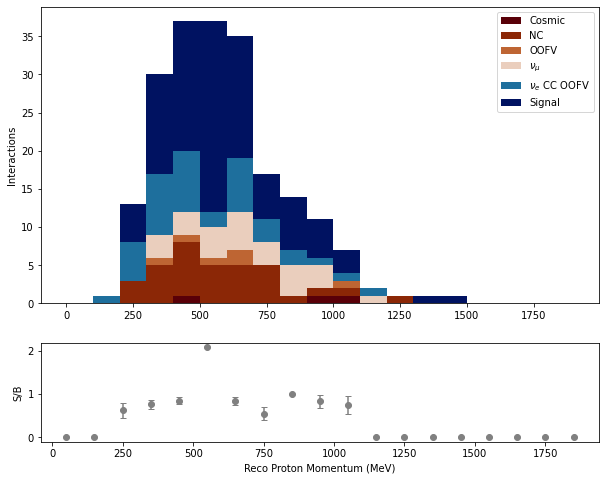

In [248]:
vals = fall['reco_leading_proton_p'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 2000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Momentum (MeV)"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


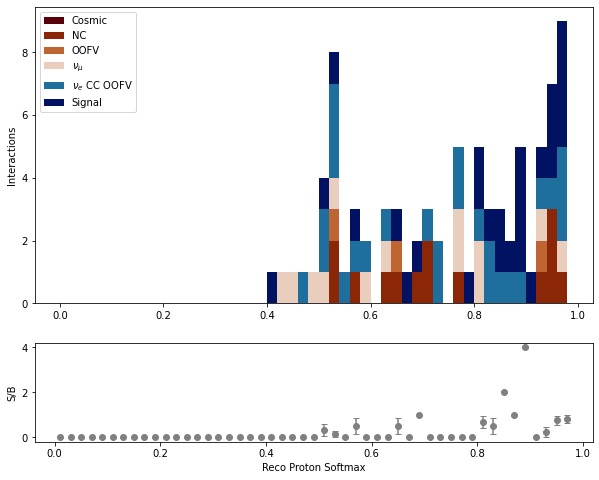

In [250]:
vals = fall['reco_leading_proton_proton_softmax'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 1, 0.02),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Softmax"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


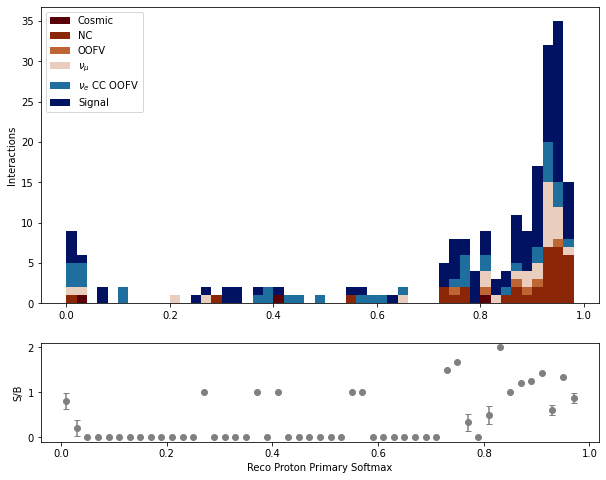

In [251]:
vals = fall['reco_leading_proton_primary_softmax'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 1, 0.02),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Primary Softmax"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


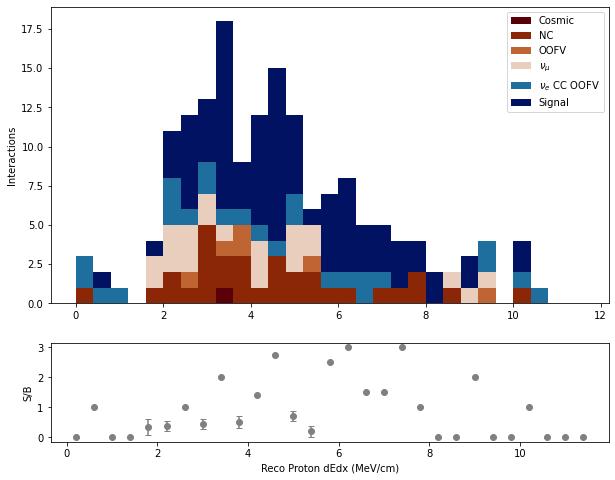

In [254]:
vals = fall['reco_leading_proton_start_dedx'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 12, 0.4),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton dEdx (MeV/cm)"
)

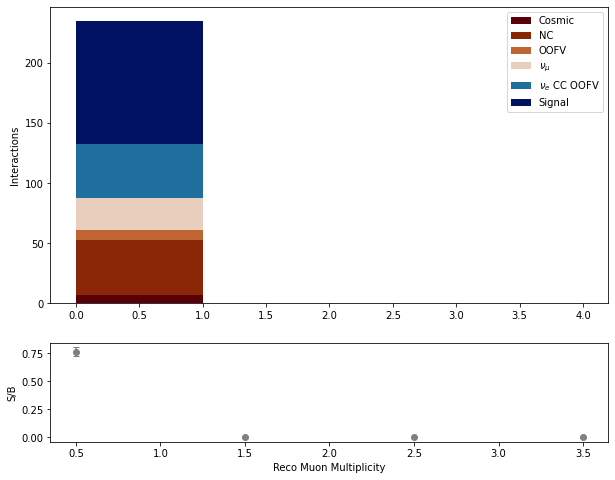

In [259]:
vals = fall['reco_muon_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 5, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Muon Multiplicity"
)

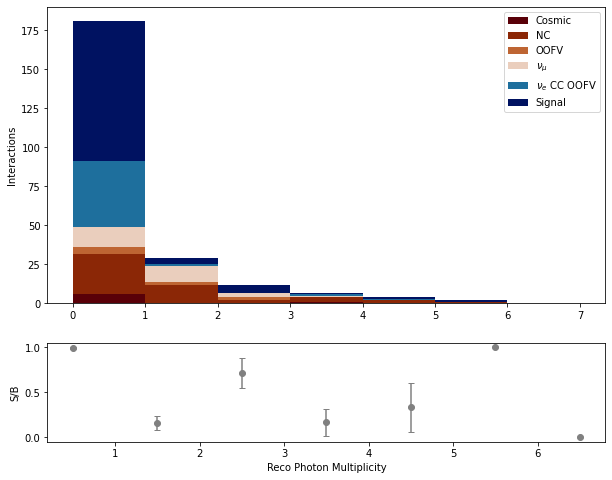

In [261]:
vals = fall['reco_photon_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 8, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Photon Multiplicity"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


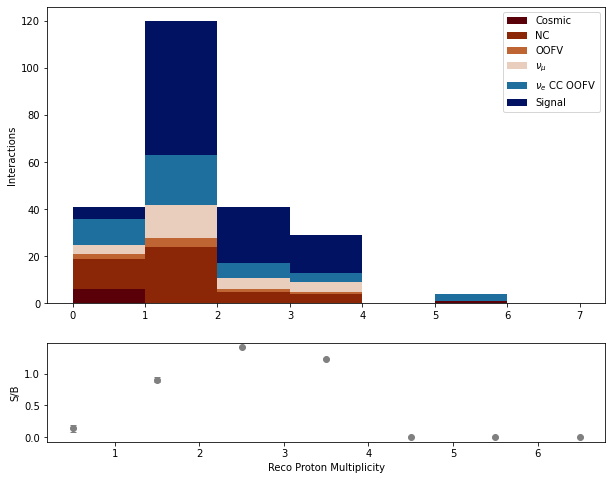

In [262]:
vals = fall['reco_proton_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 8, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Multiplicity"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


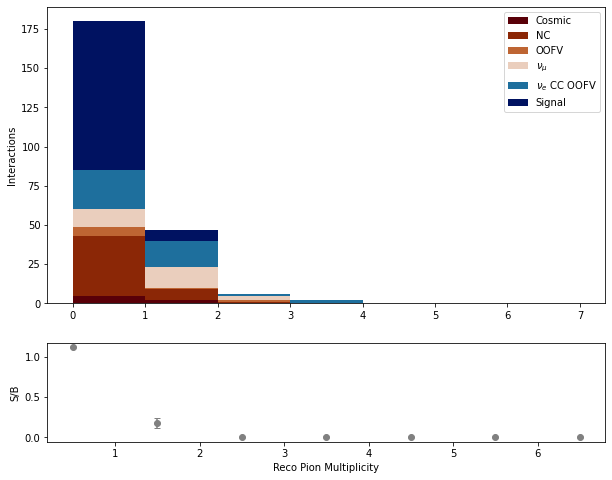

In [263]:
vals = fall['reco_pion_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 8, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Pion Multiplicity"
)

/tmp/ipykernel_1893/2574820507.py:31: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


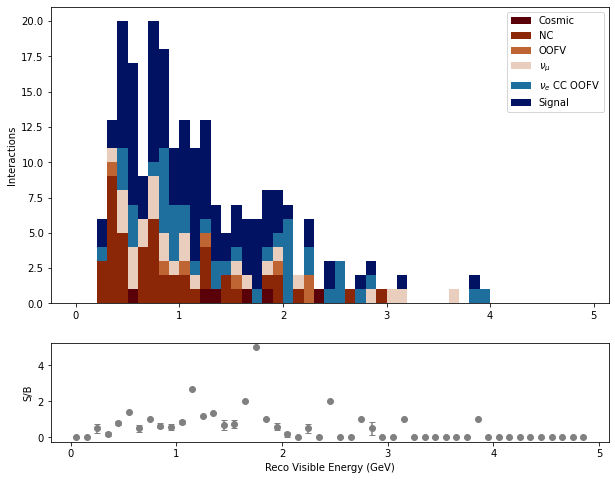

In [267]:
vals = fall['reco_visible_energy'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 5, 0.1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Visible Energy (GeV)"
)

In [134]:
fall.keys()

['reco_containment_cut',
 'reco_cut_type',
 'reco_dalphaT',
 'reco_dpL',
 'reco_dpL_lp',
 'reco_dpT',
 'reco_dpT_lp',
 'reco_dphiT',
 'reco_ele_beam_open_angle',
 'reco_electron_multiplicity',
 'reco_electron_softmax_cut',
 'reco_fiducial_cut',
 'reco_flash_cut',
 'reco_flash_time',
 'reco_has_electron',
 'reco_has_proton',
 'reco_is_data',
 'reco_is_nu',
 'reco_leading_ele_energy_cut',
 'reco_leading_electron_axial_spread',
 'reco_leading_electron_azimuthal_angle',
 'reco_leading_electron_calo_ke',
 'reco_leading_electron_containment_cut',
 'reco_leading_electron_csda_ke',
 'reco_leading_electron_directional_spread',
 'reco_leading_electron_electron_softmax',
 'reco_leading_electron_end_dir_x',
 'reco_leading_electron_end_dir_y',
 'reco_leading_electron_end_dir_z',
 'reco_leading_electron_end_x',
 'reco_leading_electron_end_y',
 'reco_leading_electron_end_z',
 'reco_leading_electron_energy',
 'reco_leading_electron_ke',
 'reco_leading_electron_length',
 'reco_leading_electron_mcs_ke',

In [ ]:
true_leading_electron_energy = fall['true_leading_electron_energy'].array(library="np")
true_leading_electron_energy_sel = true_leading_electron_energy[sel_mask]

ax, fig = plot_hist(
    vals=true_leading_electron_energy_sel,
    bins=np.arange(0, 5000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="True Leading Electron Energy (MeV)"
)

## Test different selections to maximize efficiency/purity

In [167]:
fall.keys()

['reco_containment_cut',
 'reco_cut_type',
 'reco_dalphaT',
 'reco_dpL',
 'reco_dpL_lp',
 'reco_dpT',
 'reco_dpT_lp',
 'reco_dphiT',
 'reco_ele_beam_open_angle',
 'reco_electron_multiplicity',
 'reco_electron_softmax_cut',
 'reco_fiducial_cut',
 'reco_flash_cut',
 'reco_flash_time',
 'reco_has_electron',
 'reco_has_proton',
 'reco_is_data',
 'reco_is_nu',
 'reco_leading_ele_energy_cut',
 'reco_leading_electron_axial_spread',
 'reco_leading_electron_azimuthal_angle',
 'reco_leading_electron_calo_ke',
 'reco_leading_electron_containment_cut',
 'reco_leading_electron_csda_ke',
 'reco_leading_electron_directional_spread',
 'reco_leading_electron_electron_softmax',
 'reco_leading_electron_end_dir_x',
 'reco_leading_electron_end_dir_y',
 'reco_leading_electron_end_dir_z',
 'reco_leading_electron_end_x',
 'reco_leading_electron_end_y',
 'reco_leading_electron_end_z',
 'reco_leading_electron_energy',
 'reco_leading_electron_ke',
 'reco_leading_electron_length',
 'reco_leading_electron_mcs_ke',

In [336]:
selections = []
selections.append(selection("reco_no_cut", "No Cut"))
selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
selections.append(selection("reco_flash_cut", "Flash Cut"))
#selections.append(selection("reco_valid_flashmatch", "Valid Flash Match"))
selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
selections.append(selection("reco_vertex_distance_cut", "Vertex Distance < 3.25 cm"))
#selections.append(selection("reco_track_length", "Longest Track Length < 190 cm"))
selections.append(selection("reco_has_electron", ">=1 Electron-like Particle"))
selections.append(selection("reco_no_muons", "0 Muon-like Particles", operator='==', threshold=1))
selections.append(selection("reco_no_charged_pions", "0 Charged Pion-like Particles", operator='==', threshold=1))
selections.append(selection("reco_has_proton", ">=1 Proton-like Particle"))
# selections.append(selection("reco_leading_electron_start_dedx", "Leading Electron dE/dx < 3.625 MeV/cm", operator='<', threshold=5.0))
#selections.append(selection("reco_leading_electron_containment_cut", "Leading Electron Containment Cut"))
selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.72", operator='>', threshold=0.72))
selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.97", operator='>', threshold=0.97))
selections.append(selection("reco_leading_electron_p", "Leading Electron Momentum > 25 MeV", operator='>', threshold=25))
selections.append(selection("reco_leading_proton_p", "Leading Proton Momentum > 25 MeV", operator='>', threshold=25))
selections.append(selection("reco_leading_proton_proton_softmax", "Leading Proton Softmax > 0.75", operator='>', threshold=0.75))
selections.append(selection("reco_leading_electron_axial_spread", "Leading Electron Axial Spread > 0.1", operator='>', threshold=0.1))


In [337]:
bins = [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000]

eleE = ak.nan_to_num(fall['true_leading_electron_energy'].array(), -1)
total_entries = ak.sum((fall['true_category'].array() == 0))
eff_var = ak.to_numpy(ak.where((fall['true_category'].array() == 0), 1, 0))

print("Total signal events for efficiency calculation:", total_entries)
hists = get_effHists('true_leading_electron_energy', fall, selections, eff_var = eff_var, signal_index=1, total=total_entries, bins=arr.array('d', bins), xmin=0, xmax=5000)

# total_entries = ak.sum(fevt['event_nnu_e'].array())
# hists = get_effHists('true_leading_electron_energy', fall, selections, total=total_entries, bins=arr.array('d', bins), xmin=0, xmax=5000)

c, l = plot_hists(hists, selections, "Leading Electron Energy Efficiency", "Leading Electron Energy (MeV)", "Efficiency", range=(0.01, 1.2))
c.SetLogy(0)
c.Draw()
l.Draw()

Total signal events for efficiency calculation: 185
Using provided efficiency variable array
Applying selection: No Cut
total entries in selection: 978947
Selected entries: 978947
Purity: 185/978947 = 0.0002
Efficiency after No Cut: 1.0000 (185/185)
Applying selection: Fiducial Cut
total entries in selection: 334492
Selected entries: 334492
Purity: 175/334492 = 0.0005
Efficiency after Fiducial Cut: 0.9459 (175/185)
Applying selection: Flash Cut
total entries in selection: 45609
Selected entries: 45609
Purity: 141/45609 = 0.0031
Efficiency after Flash Cut: 0.7622 (141/185)
Applying selection: Interaction Containment Cut
total entries in selection: 27145
Selected entries: 27145
Purity: 141/27145 = 0.0052
Efficiency after Interaction Containment Cut: 0.7622 (141/185)
Applying selection: Vertex Distance < 3.25 cm
total entries in selection: 1083
Selected entries: 1083
Purity: 122/1083 = 0.1127
Efficiency after Vertex Distance < 3.25 cm: 0.6595 (122/185)
Applying selection: >=1 Electron-lik

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [338]:
print_selection_stats(selections)


Selection Summary
Selection                                Slice/Int Efficiency  Neutrino Efficiency        Purity       
-------------------------------------------------------------------------------------------------------
No Cut                                       1.0000 (185/185)     1.0000 (185/185)  0.0002 (185/978947)
Fiducial Cut                                 0.9459 (175/185)     0.9459 (175/185)  0.0005 (175/334492)
Flash Cut                                    0.7622 (141/185)     0.7622 (141/185)   0.0031 (141/45609)
Interaction Containment Cut                  0.7622 (141/185)     0.7622 (141/185)   0.0052 (141/27145)
Vertex Distance < 3.25 cm                    0.6595 (122/185)     0.6595 (122/185)    0.1127 (122/1083)
>=1 Electron-like Particle                   0.6595 (122/185)     0.6595 (122/185)     0.1276 (122/956)
0 Muon-like Particles                        0.6595 (122/185)     0.6595 (122/185)     0.1459 (122/836)
0 Charged Pion-like Particles                

In [318]:
hists = get_varHists('true_leading_electron_energy', fall, bins=50, xmin=0, xmax=5000)
c, l = plot_hists(hists, selections, "Leading Electron Energy after Selections", "Reconstructed Leading Electron Energy [MeV]", "Entries", range=(1, 10e7))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (185/185)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9444 (175/185)
Applying selection: Flash Cut
Efficiency after Flash Cut: 0.7531 (141/185)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.7531 (141/185)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.6667 (122/185)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.6667 (122/185)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.6667 (122/185)
Applying selection: 0 Charged Pion-like Particles
Efficiency after 0 Charged Pion-like Particles: 0.6358 (117/185)
Applying selection: >=1 Proton-like Particle
Efficiency after >=1 Proton-like Particle: 0.5802 (107/185)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.5741 (106/185)
Applying s

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: 